<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Импорт библиотек
Для работы с научным дистрибутивом и структурами данных необходимо предварительно импортировать библиотеки NumPy и Pandas.

In [1]:
import numpy as np
import pandas as pd
import datetime

print("Библиотеки успешно импортированы!")
# Настройка отображения (опционально, как в пособии)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)

Библиотеки успешно импортированы!


### 2. Объект Series
Series — это базовая структура данных в библиотеке pandas. Серия похожа на массив NumPy, но отличается от него тем, что имеет индекс, который позволяет осуществить гораздо более гибкий поиск элементов. Вывод объекта Series состоит из двух столбцов: первый — это метка индекса, а второй — данные. Можно создавать Series как с автоматическим числовым индексом, так и с пользовательским (например, строковым).

In [2]:
# Создаем объект Series из четырех элементов (с автоматическим индексом)
s = pd.Series([1, 2, 3, 4])
print("Series с автоматическим индексом:\n", s)
print("\nЗначение для метки 1:", s[1])

# Создаем серию, задав индекс в явном виде
s_custom = pd.Series([1, 2, 3, 4], index=['a', 'b', 'c', 'd'])
print("\nSeries с буквенным индексом:\n", s_custom)

# Извлекаем значения для меток 'a' и 'd'
print("\nЭлементы с метками 'a' и 'd':\n", s_custom[['a', 'd']])

Series с автоматическим индексом:
 0    1
1    2
2    3
3    4
dtype: int64

Значение для метки 1: 2

Series с буквенным индексом:
 a    1
b    2
c    3
d    4
dtype: int64

Элементы с метками 'a' и 'd':
 a    1
d    4
dtype: int64


### 3. Работа с временными рядами в Series
Обычное использование объекта Series в pandas заключается в том, чтобы записать временной ряд, который свяжет метки индекса, записанные в виде дат и времени, со значениями. Над объектами Series можно совершать арифметические операции, а также вычислять описательные статистики (например, среднее значение).

In [3]:
# Создаем индекс из дат (включительно)
dates = pd.date_range('2016-04-01', '2016-04-06')

# Создаем два объекта Series со значениями температур
temps1 = pd.Series([80, 82, 85, 90, 83, 87], index=dates)
temps2 = pd.Series([70, 75, 69, 83, 79, 77], index=dates)

print("Температуры 1 (Missoula):\n", temps1)

# Вычисляем разницу температур (арифметическая операция)
temp_diffs = temps1 - temps2
print("\nРазница температур:\n", temp_diffs)

# Вычисляем среднее значение разности температур
print("\nСреднее значение разности температур:", temp_diffs.mean())

Температуры 1 (Missoula):
 2016-04-01    80
2016-04-02    82
2016-04-03    85
2016-04-04    90
2016-04-05    83
2016-04-06    87
Freq: D, dtype: int64

Разница температур:
 2016-04-01    10
2016-04-02     7
2016-04-03    16
2016-04-04     7
2016-04-05     4
2016-04-06    10
Freq: D, dtype: int64

Среднее значение разности температур: 9.0


### 4. Объект DataFrame
Датафрейм представляет собой один или несколько объектов Series, упорядоченных по меткам индекса. Каждая серия является столбцом в датафрейме со своим соответствующим именем. Строки можно извлекать по метке индекса с помощью свойства `.loc` или по численной позиции с помощью `.iloc`. Также в Pandas встроен механизм логического отбора строк на основе заданных условий.

In [4]:
# Создаем объект DataFrame из созданных ранее серий
temps_df = pd.DataFrame({
    'Missoula': temps1,
    'Philadelphia': temps2
})
print("Созданный DataFrame:\n", temps_df)

# Добавляем в датафрейм новый столбец Difference
temps_df['Difference'] = temp_diffs
print("\nDataFrame после добавления столбца Difference:\n", temps_df)

# Извлечение строки по позиции с помощью .iloc
print("\nВторая строка (iloc[1]):\n", temps_df.iloc[1])

# Извлечение строки по метке индекса с помощью .loc
print("\nСтрока с меткой 2016-04-05 (loc):\n", temps_df.loc['2016-04-05'])

# Логический отбор: какие температуры в Missoula > 82
print("\nЛогический отбор (температура в Missoula > 82):\n", temps_df[temps_df.Missoula > 82])

Созданный DataFrame:
             Missoula  Philadelphia
2016-04-01        80            70
2016-04-02        82            75
2016-04-03        85            69
2016-04-04        90            83
2016-04-05        83            79
2016-04-06        87            77

DataFrame после добавления столбца Difference:
             Missoula  Philadelphia  Difference
2016-04-01        80            70          10
2016-04-02        82            75           7
2016-04-03        85            69          16
2016-04-04        90            83           7
2016-04-05        83            79           4
2016-04-06        87            77          10

Вторая строка (iloc[1]):
 Missoula        82
Philadelphia    75
Difference       7
Name: 2016-04-02 00:00:00, dtype: int64

Строка с меткой 2016-04-05 (loc):
 Missoula        83
Philadelphia    79
Difference       4
Name: 2016-04-05 00:00:00, dtype: int64

Логический отбор (температура в Missoula > 82):
             Missoula  Philadelphia  Difference
2

### 5. Загрузка данных из CSV-файла и визуализация
Библиотека pandas позволяет легко загрузить данные из различных источников, например из CSV-файла, в объекты DataFrame с помощью функции `pd.read_csv()`. Параметры `parse_dates` и `index_col` позволяют автоматически преобразовать столбцы в даты и использовать их в качестве индекса. Для быстрой визуализации данных вызывается метод `.plot()`.

Данные успешно загружены! Первые 5 строк датафрейма:

                  Open        High         Low       Close   Volume
Date                                                               
2016-12-19  790.219971  797.659973  786.270020  794.200012  1225900
2016-12-20  796.760010  798.650024  793.270020  796.419983   925100
2016-12-21  795.840027  796.676025  787.099976  794.559998  1208700
2016-12-22  792.359985  793.320007  788.580017  791.260010   969100
2016-12-23  790.900024  792.739990  787.280029  789.909973   623400

Тип индекса: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Построение графика для столбца Close:


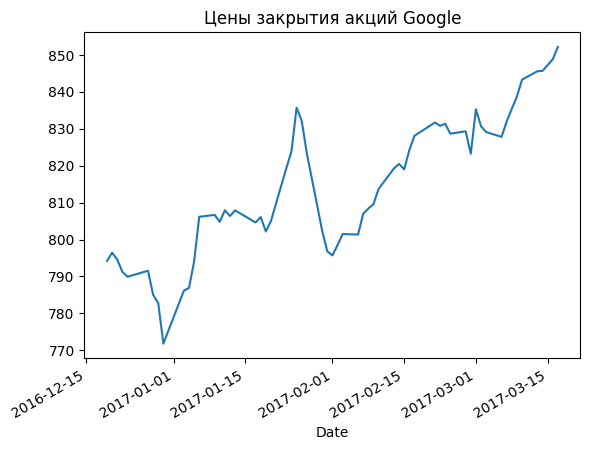

In [5]:
# ВАЖНО: Для выполнения этого кода необходимо загрузить файл 'goog.csv'
# в панель файлов слева в Google Colab.

try:
    # Считываем данные, преобразуем столбец Date в даты и делаем его индексом
    df = pd.read_csv('goog.csv', parse_dates=['Date'], index_col='Date')

    print("Данные успешно загружены! Первые 5 строк датафрейма:\n")
    print(df.head())

    print("\nТип индекса:", type(df.index))

    # Визуализируем столбец Close
    print("\nПостроение графика для столбца Close:")
    df.Close.plot(title='Цены закрытия акций Google')
except FileNotFoundError:
    print("Ошибка: Файл 'goog.csv' не найден. Пожалуйста, загрузите его в сессионное хранилище Colab.")